# Capstone Function 4
Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

 Input | Output | Goal |
|-------|--------|------|
| 3D Array (30, 4) | 1D Array (30, ) | Maximise |

## Notes
- Made a big mistake in week 1 - minimise instead of maximise!!!


# Exploratory Data Analysis

In [1]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("data/initial_inputs.npy")
initial_outputs = np.load("data/initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(30))

# save the data as a CSV file
data.to_csv("data/initial_data.csv", index=False)

(30, 4)
(30,)
     input_0   input_1   input_2   input_3     output
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.387488  

## Observations


# Gaussian Process with EI, PI and UCB

Next (UCB): [0.39490654 0.42643614 0.35274235 0.42069461]
Next (EI):  [0.49654987 0.50184189 0.01230831 0.42816807]
Next (PI):  [0.49654987 0.50184189 0.01230831 0.42816807]


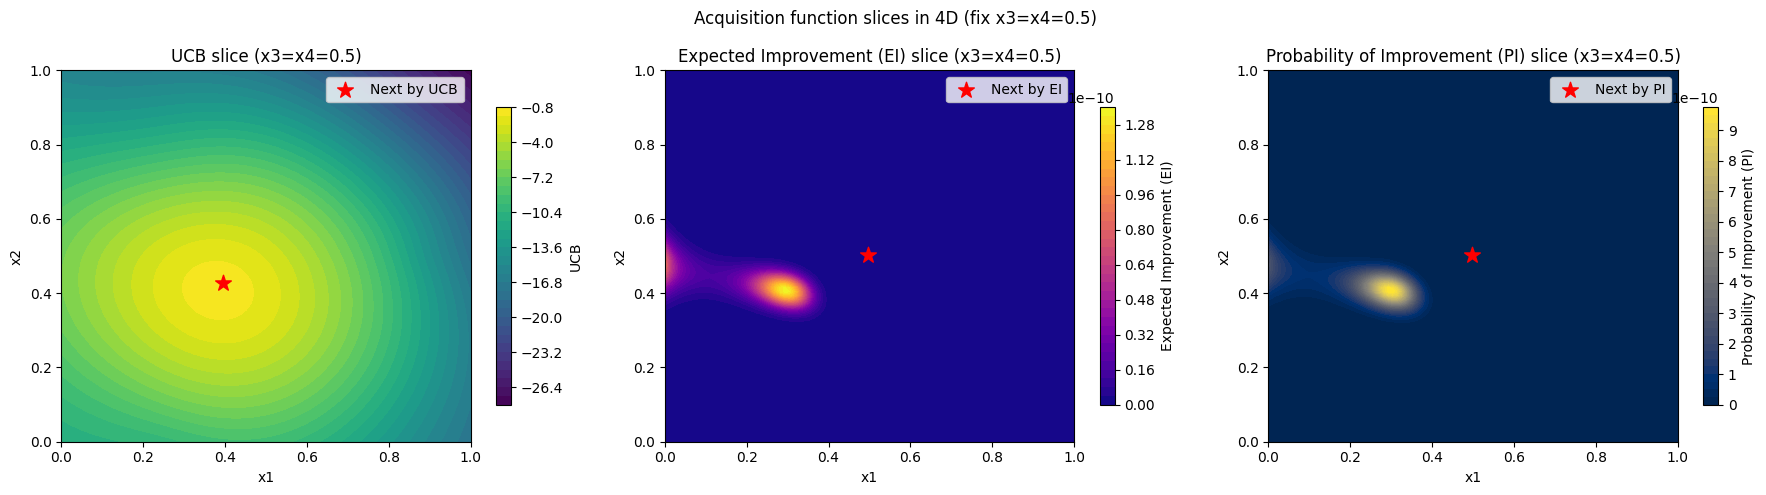

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc  # norm for EI/PI, qmc for Latin Hypercube

# ----------------------------------------------------------
# 1) GP model utilities
# ----------------------------------------------------------
def fit_gp(X, y):
    """
    Fit a Gaussian Process with ARD RBF kernel on 4D inputs.
    Assumes X is scaled to [0,1]^4 (recommended).
    """
    kernel = C(1.0, (1e-3, 1e3)) * RBF(
        length_scale=[0.3, 0.3, 0.3, 0.3],
        length_scale_bounds=(1e-2, 1e2)
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        alpha=1e-4,          # small noise term; tune for your data
        normalize_y=True
    )
    gp.fit(X, y)
    return gp

def compute_acquisitions(gp, Xcand, best_y=None, xi=0.01, kappa=2.0):
    """
    Compute UCB, EI, PI for candidate points.
    - gp: fitted GaussianProcessRegressor
    - Xcand: candidate points (m×4) in [0,1]^4
    - best_y: current best observed output (if None, take max of training y)
    - xi: small improvement margin for EI/PI
    - kappa: exploration weight for UCB
    Returns: (ucb, ei, pi, mean, std)
    """
    mean, std = gp.predict(Xcand, return_std=True)
    std = np.maximum(std, 1e-12)  # numerical safety (avoid divide-by-zero)

    if best_y is None:
        best_y = np.max(gp.y_train_)  # since normalize_y=True, this is okay for selection

    # UCB: mu + kappa*sigma
    ucb = mean + kappa * std

    # EI: (mu - best - xi) * Phi(z) + sigma * phi(z)
    z  = (mean - best_y - xi) / std
    ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

    # PI: Phi(z)
    pi = norm.cdf(z)

    return ucb, ei, pi, mean, std

def choose_next(Xcand, acq_values):
    """Return next point by maximizing the acquisition."""
    idx = int(np.argmax(acq_values))
    return Xcand[idx], idx

# ----------------------------------------------------------
# 2) Slice visualisation utilities (2D views in a 4D space)
# ----------------------------------------------------------
def make_slice(gp, which='12', grid=100, fixed=(0.5, 0.5), xi=0.01, kappa=2.0):
    """
    Compute a 2D slice of UCB, EI, PI.
    which='12' -> slice over (x1,x2) with (x3,x4)=fixed
    which='34' -> slice over (x3,x4) with (x1,x2)=fixed
    Returns (X1, X2, UCB_slice, EI_slice, PI_slice)
    """
    x = np.linspace(0, 1, grid)
    X1, X2 = np.meshgrid(x, x)
    if which == '12':
        Xslice = np.column_stack([
            X1.ravel(), X2.ravel(),
            np.full(grid*grid, fixed[0]), np.full(grid*grid, fixed[1])
        ])
    else:
        Xslice = np.column_stack([
            np.full(grid*grid, fixed[0]), np.full(grid*grid, fixed[1]),
            X1.ravel(), X2.ravel()
        ])
    ucb, ei, pi, _, _ = compute_acquisitions(gp, Xslice, xi=xi, kappa=kappa)
    return X1, X2, ucb.reshape(grid, grid), ei.reshape(grid, grid), pi.reshape(grid, grid)

#-------------------- Main Program --------------------

# Load the dataset
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Fit GP
gp = fit_gp(X, y)

# Candidate set via Latin Hypercube in [0,1]^4
M = 6000
sampler = qmc.LatinHypercube(d=4, seed=123)
Xcand = sampler.random(M)

# Compute acquisitions and pick next points for UCB, EI, PI
kappa = 2.0  # ↑ explore; ↓ exploit
xi    = 0.01 # small margin for EI/PI
ucb_vals, ei_vals, pi_vals, _, _ = compute_acquisitions(gp, Xcand, xi=xi, kappa=kappa)
next_ucb, idx_ucb = choose_next(Xcand, ucb_vals)
next_ei,  idx_ei  = choose_next(Xcand, ei_vals)
next_pi,  idx_pi  = choose_next(Xcand, pi_vals)

print("Next (UCB):", next_ucb)
print("Next (EI): ", next_ei)
print("Next (PI): ", next_pi)

# ---- Visualise acquisition slices over (x1, x2) at (x3, x4) = 0.5 ----
X1, X2, UCB_s, EI_s, PI_s = make_slice(
    gp, which='12', grid=100, fixed=(0.5, 0.5), xi=xi, kappa=kappa
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps  = ['viridis', 'plasma', 'cividis']
labels = ['UCB', 'Expected Improvement (EI)', 'Probability of Improvement (PI)']
arrays = [UCB_s, EI_s, PI_s]

for ax, arr, lab, cmap in zip(axes, arrays, labels, cmaps):
    cs = ax.contourf(X1, X2, arr, levels=40, cmap=cmap)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_title(lab + ' slice (x3=x4=0.5)')
    fig.colorbar(cs, ax=ax, shrink=0.8, label=lab)

# Overlay the projected best-next points onto this slice
axes[0].scatter(next_ucb[0], next_ucb[1], c='red', marker='*', s=140, label='Next by UCB')
axes[1].scatter(next_ei[0],  next_ei[1],  c='red', marker='*', s=140, label='Next by EI')
axes[2].scatter(next_pi[0],  next_pi[1],  c='red', marker='*', s=140, label='Next by PI')
for ax in axes:
    ax.legend(loc='upper right')

plt.suptitle('Acquisition function slices in 4D (fix x3=x4=0.5)')
plt.tight_layout()
plt.savefig('acq_slices_4d.png')  # saved image file
plt.show()


# Week 1 Submission
0.496549-0.501841-0.012308-0.428168

---
---
## Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Review which acquisition function to use

Suggested new points: [[0.5438567359577052, 0.42848089760911273, 0.41584523761396064, 0.2689823708150788]]


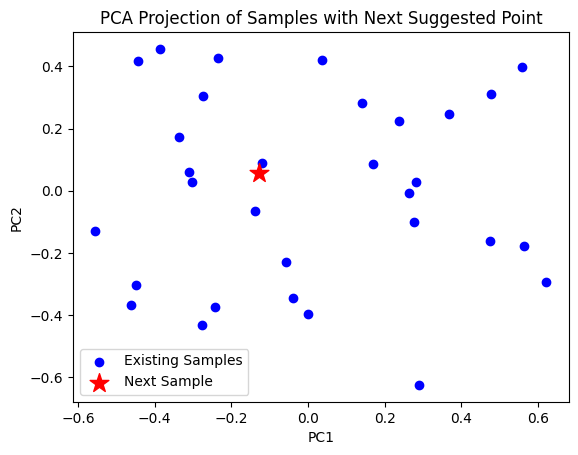

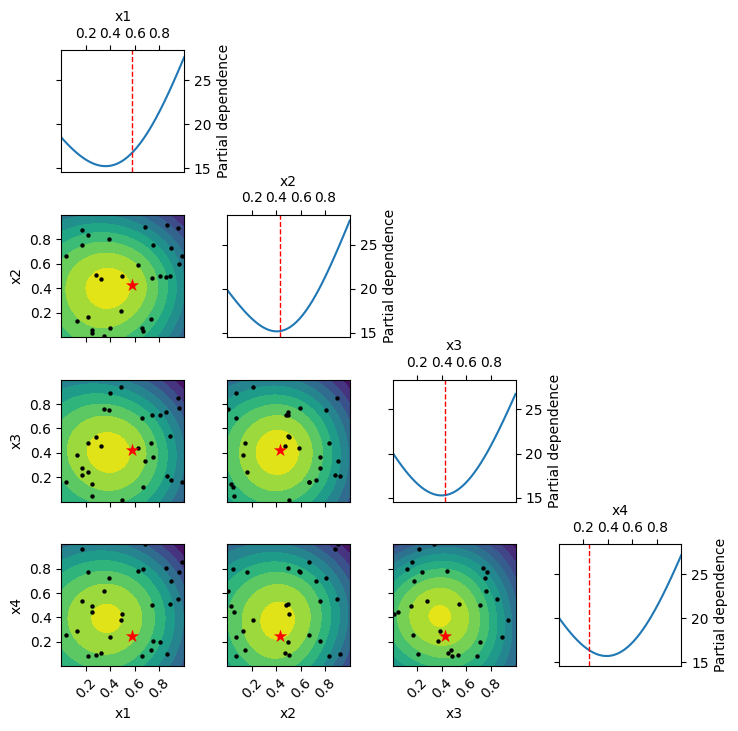

In [4]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([00.496549, 0.501841, 0.012308, 0.428168])
y.append(-9.720481)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose new point
print("Suggested new points:", next_points)

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_points))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.543856-0.428480-0.415845-0.268982

---
---
# Week 3

Suggested new points: 0.427629-0.419856-0.400742-0.398136


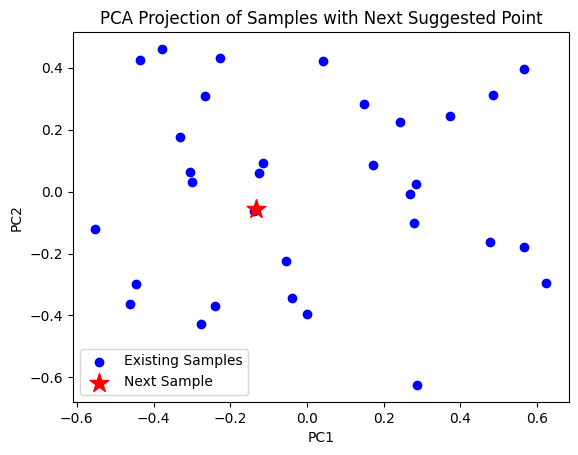

00. X: 0.896981, 0.725628, 0.175404, 0.701694, y:      -22.108288
01. X: 0.889356, 0.499588, 0.539269, 0.508783, y:      -14.601397
02. X: 0.250946, 0.033693, 0.145380, 0.494932, y:      -11.699932
03. X: 0.346962, 0.006250, 0.760564, 0.613024, y:      -16.053765
04. X: 0.124871, 0.129770, 0.384400, 0.287076, y:      -10.069633
05. X: 0.801303, 0.500231, 0.706645, 0.195103, y:      -15.487083
06. X: 0.247708, 0.060445, 0.042186, 0.441324, y:      -12.681685
07. X: 0.746702, 0.757092, 0.369353, 0.206566, y:      -16.026400
08. X: 0.400665, 0.072574, 0.886768, 0.243842, y:      -17.049235
09. X: 0.626071, 0.586751, 0.438806, 0.778858, y:      -12.741766
10. X: 0.957135, 0.597644, 0.766114, 0.776210, y:      -27.316396
11. X: 0.732812, 0.145250, 0.476813, 0.133366, y:      -13.527649
12. X: 0.655115, 0.072392, 0.687152, 0.081517, y:      -16.679115
13. X: 0.219734, 0.832031, 0.482864, 0.082569, y:      -16.507159
14. X: 0.488594, 0.211965, 0.939178, 0.376192, y:      -17.817999
15. X: 0.1

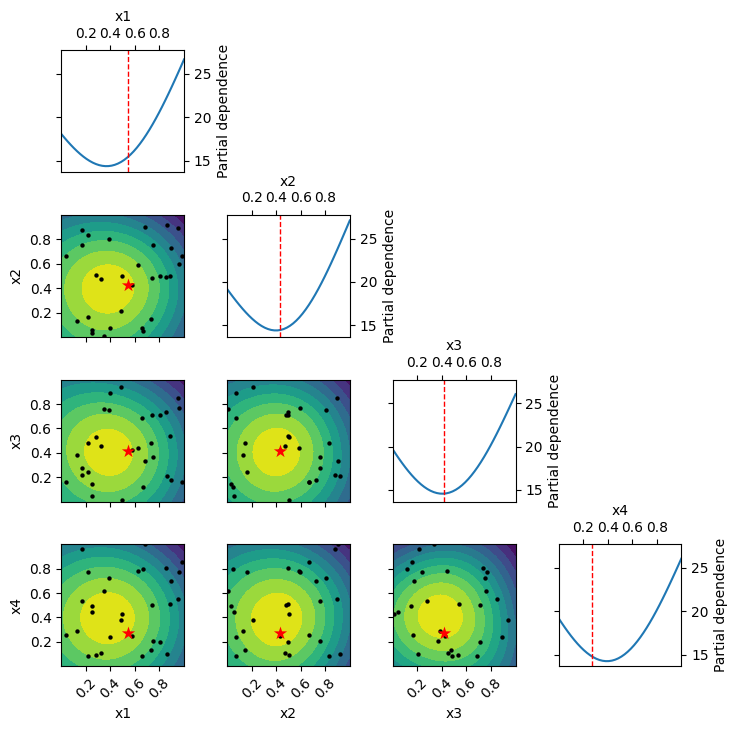

In [13]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="EI", random_state=42, acq_func_kwargs={'xi': 0.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.496549, 0.501841, 0.012308, 0.428168])
y.append(-9.720481)

# insert a new observation for week 3
X.append([0.543856, 0.428480, 0.415845, 0.268982])
y.append(-2.912759)


# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose new point
print(f"Suggested new points: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_point))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")

---
---
# Week 4

## Hyperparameter selection
- significant convergence over recent sample - favour exploitation
- Acquisition Function - EI
- xi = 0

Suggested new point: 0.389272-0.417332-0.404425-0.438075


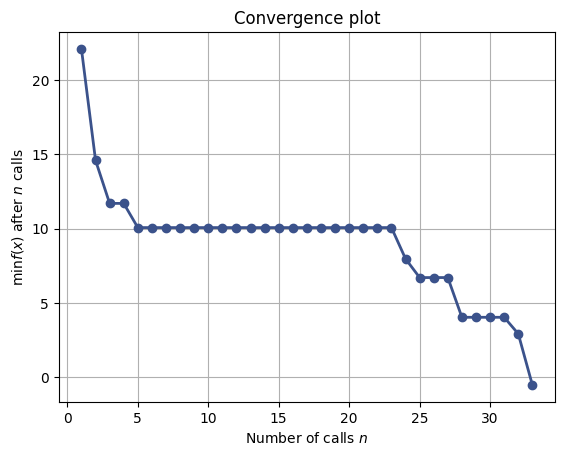

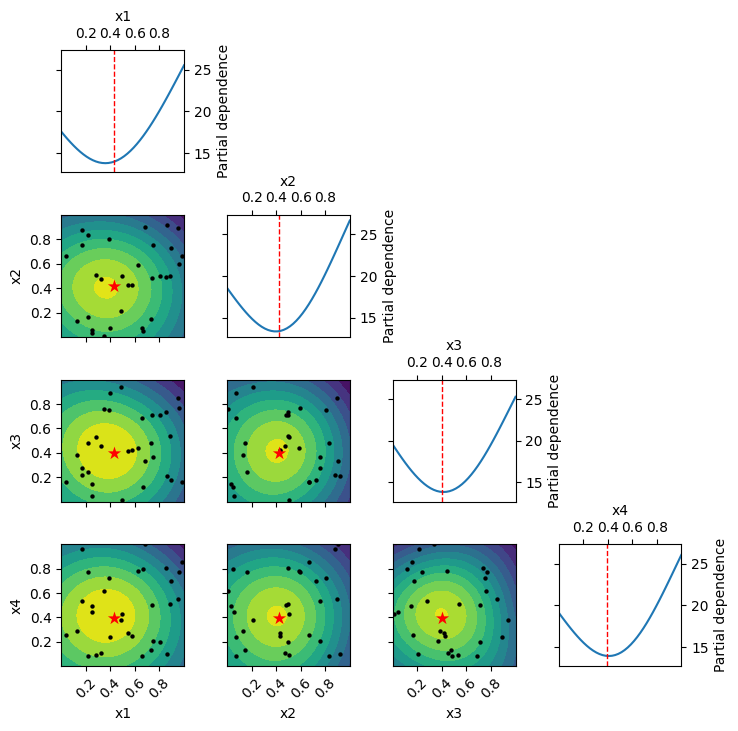

In [3]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f4/updated_inputs.npy").tolist()
y = np.load("../data/f4/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)




---
---
# Week 5

## Hyperparameter selection - Last Week
- significant convergence over recent sample - favour exploitation
- Acquisition Function - EI
- xi = 0

Suggested new point: 0.427533-0.394652-0.375253-0.434006


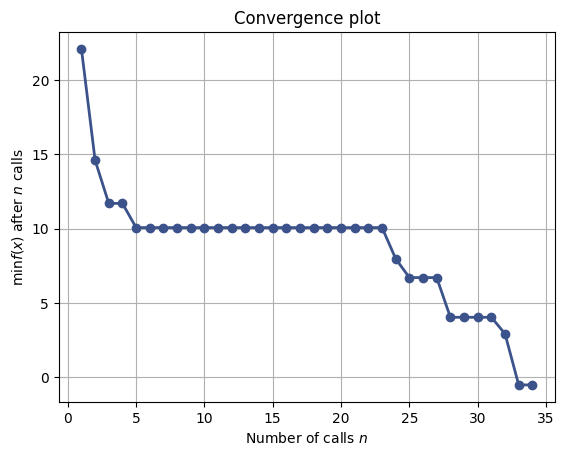

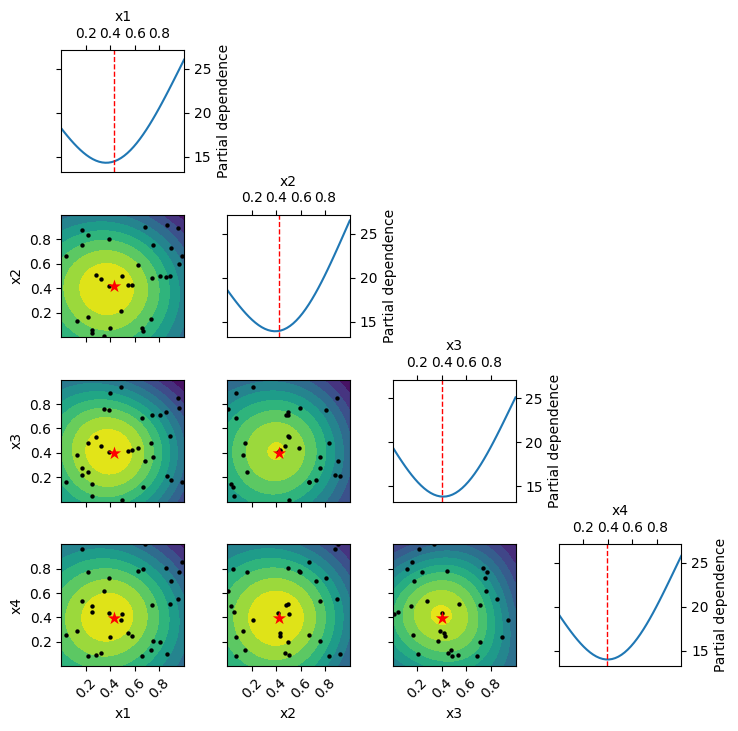

In [4]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data (10 samples)
X = np.load("../data/f4/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f4/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


